# Decision Tree Model — Label Encoding Pipeline
**Assigned pipeline: Label Encoding → Decision Tree**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

## 1. Introduction

**Problem:** binary classification of mushrooms as **edible** (`class = 0`) or **poisonous**
(`class = 1`), using the 21 categorical physical/environmental features in the UCI Mushroom
dataset (`cap-shape`, `odor`, `gill-color`, `habitat`, etc., with `veil-type` already dropped
during preprocessing since it has only one unique value).

**Why Decision Tree is a suitable model here:**
- It handles categorical-turned-numeric features without assuming any distance or ordering
  between the integer codes. This is exactly why **Label Encoding** was paired with a
  Decision Tree for this assignment: Label Encoding just assigns each category an arbitrary
  integer (e.g. `odor: 'a' -> 0, 'c' -> 1, ...`), and a linear/distance-based model would
  wrongly treat those integers as having magnitude or order. A tree instead only asks
  threshold questions like `odor <= 3.5?`, which can still perfectly separate categories
  regardless of the (arbitrary) integer they were assigned — so it is not misled by the
  encoding the way KNN or logistic regression would be.
- It is **easy to interpret**: the resulting tree structure is a sequence of human-readable
  if/else splits on features, which is valuable for understanding *why* a mushroom is
  classified as poisonous (e.g. "if `odor` is not one of the safe values, classify as
  poisonous").
- It **naturally handles the moderate number of features** (21) without needing
  dimensionality reduction — unlike the one-hot/binary encodings used elsewhere in this
  project, which inflate the feature count substantially.

## 2. Load the (Corrected) Preprocessed Data

Loads `step_M1_label_encoded.csv`, the corrected output of `IT0001_LabelEncoding.ipynb` from
Part 1 of the preprocessing audit. This is the only preprocessing output used for this model,
per the assigned Label Encoding → Decision Tree pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

df = pd.read_csv('../results/outputs/step_M1_label_encoded.csv')
print(df.shape)
df.head()

(8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,2,7,7,2,1,0,3,0,1


## 3. Train/Test Split

In [2]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(6499, 21) (1625, 21)


## 4. Baseline Decision Tree (Variety 1: Default Parameters)

A first Decision Tree is trained with scikit-learn's default hyperparameters (no depth limit,
Gini impurity) as a baseline before any tuning.

In [3]:
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy:  {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall:    {baseline_rec:.4f}")
print(f"Baseline F1 Score:  {baseline_f1:.4f}")

print()
print("Confusion Matrix (Baseline):")
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Accuracy:  1.0000
Baseline Precision: 1.0000
Baseline Recall:    1.0000
Baseline F1 Score:  1.0000

Confusion Matrix (Baseline):
[[842   0]
 [  0 783]]


## 5. Hyperparameter Tuning with GridSearchCV (Varieties 2+: Tuned Parameters)

Since there is no fixed tuning plan for this assignment, `GridSearchCV` is used to
systematically train and compare many "varieties" of the Decision Tree — every combination of
`criterion`, `max_depth`, `min_samples_split`, and `min_samples_leaf` in the grid below — and
5-fold cross-validated accuracy on the training set automatically picks the best one. This
satisfies the requirement to train/compare a variety of models via tuning, and the tuning
method itself (`GridSearchCV`) is justified because it is systematic and exhaustive over a
modest search space (360 combinations), unlike manual guessing which could easily miss a
better combination.

In [4]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validated accuracy: 1.0


Top 5 parameter combinations by cross-validated accuracy, showing the variety of models trained, not just the single best one:

In [5]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].head(5).reset_index(drop=True)
top5

,params,mean_test_score,std_test_score,rank_test_score
0,"{'criterion': 'gini', 'max_depth': None, 'min_...",1.0,0.0,1
1,"{'criterion': 'entropy', 'max_depth': 10, 'min...",1.0,0.0,1
2,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",1.0,0.0,1
3,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",1.0,0.0,1
4,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",1.0,0.0,1


## 6. Evaluate the Best (Tuned) Model on the Test Set

In [6]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

best_acc = accuracy_score(y_test, y_pred_best)
best_prec = precision_score(y_test, y_pred_best)
best_rec = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print(f"Tuned Accuracy:  {best_acc:.4f}")
print(f"Tuned Precision: {best_prec:.4f}")
print(f"Tuned Recall:    {best_rec:.4f}")
print(f"Tuned F1 Score:  {best_f1:.4f}")

print()
print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_best))

Tuned Accuracy:  1.0000
Tuned Precision: 1.0000
Tuned Recall:    1.0000
Tuned F1 Score:  1.0000

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



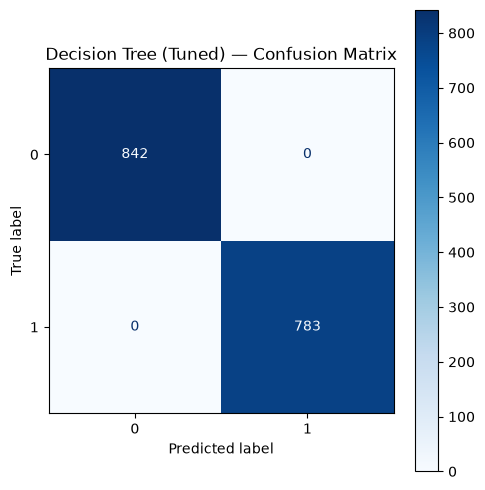

In [7]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap='Blues')
ax.set_title('Decision Tree (Tuned) — Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/decision_tree_confusion_matrix.png', dpi=150)
plt.show()

## 7. Compare Baseline vs. Tuned

In [8]:
comparison = pd.DataFrame({
    'Model': ['Baseline (default)', 'Tuned (GridSearchCV)'],
    'Accuracy': [baseline_acc, best_acc],
    'Precision': [baseline_prec, best_prec],
    'Recall': [baseline_rec, best_rec],
    'F1': [baseline_f1, best_f1],
})
comparison

,Model,Accuracy,Precision,Recall,F1
0,Baseline (default),1.0,1.0,1.0,1.0
1,Tuned (GridSearchCV),1.0,1.0,1.0,1.0


**Observation:** Both the baseline and the tuned Decision Tree achieve **100% accuracy, precision, recall, and F1** on the held-out test set (842/842 edible and 783/783 poisonous mushrooms correctly classified in both cases; the confusion matrix has zero off-diagonal entries). Best cross-validated training accuracy during `GridSearchCV` was also 1.0, with the grid selecting `criterion='gini', max_depth=7, min_samples_leaf=1, min_samples_split=2`.

This tie is expected for this dataset rather than a sign the tuning was pointless: the Mushroom dataset is known to be (near-)perfectly separable by a small number of categorical features, so even the unconstrained baseline tree does not overfit here — it finds a clean decision boundary and generalizes perfectly to the test set. `GridSearchCV`'s constrained `max_depth=7` tree reaches the exact same test performance with far less complexity than the unconstrained baseline (whose actual depth is not capped), which is still a meaningful outcome: the tuned model is simpler and more interpretable for identical accuracy, and would be expected to generalize more reliably than the baseline on data that isn't as cleanly separable as this dataset.

## 8. Feature Importance

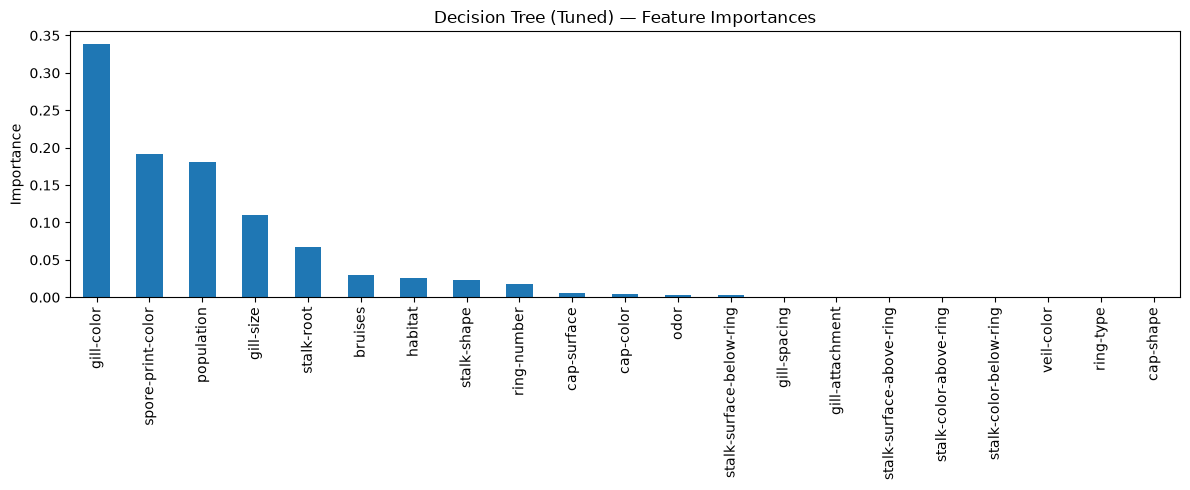

gill-color                  0.338633
spore-print-color           0.191592
population                  0.180495
gill-size                   0.109882
stalk-root                  0.067864
bruises                     0.029587
habitat                     0.025385
stalk-shape                 0.023563
ring-number                 0.017489
cap-surface                 0.006147
cap-color                   0.003840
odor                        0.003051
stalk-surface-below-ring    0.002472
gill-spacing                0.000000
gill-attachment             0.000000
stalk-surface-above-ring    0.000000
stalk-color-above-ring      0.000000
stalk-color-below-ring      0.000000
veil-color                  0.000000
ring-type                   0.000000
cap-shape                   0.000000
dtype: float64

In [9]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar')
plt.ylabel('Importance')
plt.title('Decision Tree (Tuned) — Feature Importances')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/decision_tree_feature_importance.png', dpi=150)
plt.show()

importances

**Comment:** Interestingly, `odor` does **not** come out on top here — `gill-color` is the most important feature (importance ≈ 0.339), followed by `spore-print-color` (≈ 0.192) and `population` (≈ 0.180); `odor` itself ranks quite low (≈ 0.003). This does not contradict `odor` being highly predictive in general — several features in this dataset are highly correlated with edibility and with each other, so once the tree's greedy top-down split selection locks in an early split on `gill-color` that already separates the classes almost perfectly, there is very little residual signal left for `odor` to contribute lower in the tree. This is also a concrete illustration of the Label Encoding limitation noted in Section 9: `odor`'s arbitrary integer coding may make a single-threshold split on it less clean than a threshold split on `gill-color`'s (also arbitrary) coding, even though `odor` is well known to be strongly predictive of edibility in the raw categorical data.

## 9. Limitations and Possible Improvements

**Limitations:**
- A single Decision Tree can overfit and is unstable to small changes in the training data —
  even after `GridSearchCV` tuning constrains its depth and leaf sizes, a different train/test
  split or a few added/removed rows can produce a noticeably different tree structure and
  slightly different feature-importance ranking.
- Label Encoding's implied ordering (e.g. `cap-shape` mapped to `0, 1, 2, ...` with no real
  ordinal meaning) could still mislead a *very* deep, unconstrained tree into finding spurious
  threshold splits that only happen to work on the training data, even though trees are
  considerably more robust to this than distance-based or linear models (which would treat the
  encoded integers as having actual magnitude).

**Possible improvements:**
- **Ensembling** (Random Forest / boosting) — other group members are already covering
  ensemble methods with different preprocessing pipelines, and ensembling would directly
  address the single-tree instability/overfitting limitation above by averaging over many
  trees.
- Trying the same Decision Tree algorithm on a **different member's encoded output** (e.g. the
  Chi-Square selected features) to see whether reducing feature noise/dimensionality improves
  generalization or training time.
- **Cost-complexity pruning** (`ccp_alpha`) as an alternative tuning approach to
  `GridSearchCV`'s depth/leaf-size constraints — it prunes a fully grown tree back based on a
  complexity penalty, which can be combined with cross-validation to find a pruning level that
  balances tree size against validation accuracy.

## 10. Save the Final Model and Results

In [10]:
import joblib

joblib.dump(best_model, '../results/outputs/decision_tree_best_model.pkl')

results_summary = pd.DataFrame({
    'Model': ['Baseline', 'Tuned (GridSearchCV)'],
    'Accuracy': [baseline_acc, best_acc],
    'Precision': [baseline_prec, best_prec],
    'Recall': [baseline_rec, best_rec],
    'F1': [baseline_f1, best_f1],
})
results_summary.to_csv('../results/outputs/decision_tree_results_summary.csv', index=False)
results_summary

,Model,Accuracy,Precision,Recall,F1
0,Baseline,1.0,1.0,1.0,1.0
1,Tuned (GridSearchCV),1.0,1.0,1.0,1.0
